# Model 3a: Daily Maximum Geopolitical Indices

This notebook extends the selected Model 3 VAR-X specification by incorporating the **daily maximum** LLM-derived geopolitical-risk indices.

The endogenous variables remain:

- EUR/USD log returns (`DEXUSEU_logreturn`)
- changes in the US Economic Policy Uncertainty Index (`USEPUINDXD_diff`)

The exogenous variables are:

- VIX (`VIXCLS`)
- changes in the US 2-Year Treasury yield (`DGS2_diff`)
- daily maximum Trade Hostility (`trade_max`)
- daily maximum Sanctions Threat (`sanctions_max`)
- changes in daily maximum Federal Reserve Pressure (`fed_pressure_max_diff`)

The daily maximum specification captures the most intense geopolitical signal observed within each category on a given day.

Model 3a is evaluated using the same VAR-X framework and held-out forecasting procedure as the macroeconomic baseline so that the effect of introducing geopolitical information can be assessed consistently.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

from matplotlib.backends.backend_pdf import PdfPages

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
try:
    from statsmodels.tsa.statespace.varmax import VARMAX
except ImportError:
    from statsmodels.tsa.api import VARMAX
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
# Configuration cell 
ENDOG_COLS = ["DEXUSEU_logreturn", "USEPUINDXD_diff"]
EXOG_COLS = ["VIXCLS", "DGS2_diff", "trade_max", "sanctions_max", "fed_pressure_max_diff"]
N_TEST = 20
MAX_LAG = 12
SIGNIF = 0.05

In [3]:
# Function for loading and preparing data
def load_data(path, date_col="Date"):
    """Load a CSV, parse dates, set datetime index, sort chronologically."""
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    return df

# Function for splitting the dataframe into endogenous and exogenous variables
def split_endog_exog(df):
    """Split the loaded dataframe into endogenous and exogenous blocks per CONFIG."""
    missing = [c for c in ENDOG_COLS + EXOG_COLS if c not in df.columns]
    if missing:
        raise KeyError(f"Columns in CONFIG but not in data: {missing}")
    return df[ENDOG_COLS].copy(), df[EXOG_COLS].copy()

# Function for plotting the time series data
def plot_series(df, save_path=None):
    """Plot each column in its own panel for visual inspection."""
    n = len(df.columns)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(8, 2.2 * n), dpi=120, squeeze=False)
    for ax, col in zip(axes.flatten(), df.columns):
        ax.plot(df.index, df[col], linewidth=1)
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
    return fig

# Function for performing pairwise Granger causality tests
# This test checks whether lagged values of one endogenous variable improve the
# prediction of another endogenous variable, beyond what the variable's own lags
# already explain.
# The output is a matrix of the minimum p-values across tested lags for each pair.

def granger_matrix(df, maxlag=MAX_LAG, test="ssr_chi2test"):
    """Pairwise Granger causality p-values. Rows = response (y), columns = predictor (x).
    Cell value = min p-value across lags 1..maxlag. Run on ENDOG columns only."""
    variables = df.columns
    mat = pd.DataFrame(np.zeros((len(variables), len(variables))),
                       columns=variables, index=variables)
    for c in mat.columns:
        for r in mat.index:
            if r == c:
                mat.loc[r, c] = np.nan
                continue
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", FutureWarning)
                res = grangercausalitytests(df[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [res[lag][0][test][1] for lag in range(1, maxlag + 1)]
            mat.loc[r, c] = np.min(p_values)
    mat.columns = [v + "_x" for v in variables]
    mat.index = [v + "_y" for v in variables]
    return mat



# Function for performing the Johansen cointegration test
# The Johansen test checks whether multiple time series share a long-run equilibrium.
# It identifies the number of cointegrating relationships among the endogenous variables.
def cointegration_test(df, alpha=SIGNIF, det_order=0, k_ar_diff=5):
    """Johansen trace test. Row 'r<=i' rejected => more than i cointegrating relations.
    Run on ENDOG columns in LEVELS (not differenced)."""
    res = coint_johansen(df, det_order, k_ar_diff)
    col = {0.90: 0, 0.95: 1, 0.99: 2}[round(1 - alpha, 2)]
    out = pd.DataFrame({
        "trace_stat": res.lr1,
        f"crit_{int((1 - alpha) * 100)}%": res.cvt[:, col],
    }, index=[f"r<={i}" for i in range(len(res.lr1))])
    out["reject"] = out["trace_stat"] > out.iloc[:, 1]
    return out

# Functions for performing the Augmented Dickey-Fuller (ADF) test
# The Augmented Dickey-Fuller test checks whether a time series has a unit root.
# The null hypothesis is that the series is non-stationary.
# A series "passes" the test when the p-value is below the significance level,
# meaning the null is rejected and the series is likely stationary.
# If the p-value is above the threshold, the series often needs differencing or
# another transformation before re-testing for stationarity.
def adf_report(series, signif=SIGNIF):
    """ADF test on one series. Null: unit root (non-stationary)."""
    stat, pvalue, nlags, nobs, crit, icbest = adfuller(series.dropna(), autolag="AIC")
    return {"variable": series.name, "adf_stat": round(stat, 4),
            "pvalue": round(pvalue, 4), "n_lags": nlags,
            "stationary": pvalue <= signif}

def run_adf_all(df, signif=SIGNIF):
    """ADF on every column; returns one summary dataframe."""
    return pd.DataFrame([adf_report(df[c], signif) for c in df.columns]).set_index("variable")



def plot_stationarity(df, save_path=None, signif=SIGNIF):
    """For each column: level (left) vs 1st difference (right),
    with the ADF p-value and verdict embedded in each panel title."""
    n = len(df.columns)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(11, 2.4 * n), dpi=120, squeeze=False)
    diffed = df.diff()
    for i, col in enumerate(df.columns):
        for j, (data, label) in enumerate([(df[col], "level"), (diffed[col], "1st difference")]):
            p = adfuller(data.dropna(), autolag="AIC")[1]
            ax = axes[i, j]
            ax.plot(data.index, data, linewidth=0.9)
            verdict = "stationary" if p <= signif else "NON-stationary"
            ax.set_title(f"{col} ({label}) - ADF p={p:.4f} [{verdict}]", fontsize=8)
            ax.tick_params(labelsize=6)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
    return fig

# Functions for differencing until stationarity
# NOTE: The following section contains functions to repeatedly
# difference the entire dataframe until all series pass the ADF
# stationarity test. These functions operate on the whole frame
# (not column-by-column) to keep a consistent order of integration
# across variables for multivariate modelling.
# Be cautious: this may over-difference already-stationary series (n_diffs > 2 may be risky).


def _all_stationary(df, signif=SIGNIF):
    """True if every column passes the ADF test."""
    return all(adfuller(df[c].dropna(), autolag="AIC")[1] <= signif
               for c in df.columns)

def difference_until_stationary(df, signif=SIGNIF, max_diffs=2):
    """Difference the WHOLE frame until all columns are stationary.
    Returns (differenced_df, n_diffs). n_diffs is needed later to invert forecasts."""
    n_diffs = 0
    out = df.copy()
    while not _all_stationary(out, signif) and n_diffs < max_diffs:
        out = out.diff().dropna()
        n_diffs += 1
    if not _all_stationary(out, signif):
        raise ValueError(f"Still non-stationary after {max_diffs} differences - inspect the data.")
    return out, n_diffs


# Drawbacks of differencing already-stationary variables:
# - Over-differencing (applying differences to series that are already
# stationary) can remove meaningful long-run information and introduce
# moving-average structure, complicating model identification.
# - It can increase noise and reduce signal-to-noise ratio, degrading
# forecasting performance and interpretability.
# - Differencing changes the series' variance/stochastic properties and
# may necessitate additional modelling choices (e.g. extra lags, MA
# terms) to capture the induced dynamics.
# - Because this function diffs the whole frame, a single non-stationary
# series forces differencing of all variables; this may be undesirable if
# some variables are already stationary and should remain in levels.

# Consider alternatives when appropriate:
# - Test and difference each series individually, tracking orders of
# integration per variable.

# Function for splitting the dataset into training and testing sets
def train_test_split_ts(endog, exog, n_test=N_TEST):
    """Chronological split - LAST n_test rows held out, never random.
    Aligns endog and exog to their common index first, so unequal
    differencing upstream can't silently desynchronise the frames.
    Returns (endog_train, endog_test, exog_train, exog_test)."""
    common = endog.index.intersection(exog.index)
    endog, exog = endog.loc[common], exog.loc[common]
    return (endog.iloc[:-n_test], endog.iloc[-n_test:],
            exog.iloc[:-n_test], exog.iloc[-n_test:])


# Function for selecting the optimal lag order for VAR-X model
def select_lag_order(endog, exog=None, max_lag=6):
    """Fit VARMAX(p, 0) for p = 1..max_lag; return AIC/BIC/HQIC per lag.
    Why VARMAX not VAR: plain statsmodels VAR has no exog support, and
      lag selection must happen in the SAME model class you'll estimate.
    Watch for: converged=False rows - their information criteria are
      untrustworthy; also MLE runtime grows fast with k and p."""
    rows = []
    for p in range(1, max_lag + 1):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            res = VARMAX(endog, exog=exog, order=(p, 0)).fit(disp=False)
        rows.append({"lag": p, "aic": res.aic, "bic": res.bic, "hqic": res.hqic,
                     "converged": res.mle_retvals.get("converged", None)})
    return pd.DataFrame(rows).set_index("lag")


def plot_lag_selection(lag_tbl, save_path=None):
    """AIC/BIC/HQIC vs lag order; circled point = each criterion's minimum."""
    fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
    for crit in ["aic", "bic", "hqic"]:
        ax.plot(lag_tbl.index, lag_tbl[crit], marker="o", label=crit.upper())
        best = lag_tbl[crit].idxmin()
        ax.scatter([best], [lag_tbl.loc[best, crit]], s=150, facecolors="none",
                   edgecolors="black", zorder=5)
    ax.set_xlabel("lag order p"); ax.set_ylabel("criterion")
    ax.set_xticks(lag_tbl.index)
    ax.legend(); ax.set_title("Lag order selection (circled = minimum)")
    plt.tight_layout()
    if save_path: fig.savefig(save_path)
    return fig

def plot_cross_correlations(endog, exog=None, max_lag=10, save_path=None):
    """Grid of corr(predictor(t-k), response(t)) for k = 0..max_lag.
    Rows = responses (endog), columns = predictors (endog + exog).
    Dashed lines: approximate 95% band (+/- 2/sqrt(n)).
    Shows WHERE relationships live in lag-space; the VAR still uses one system-wide p."""
    df = endog if exog is None else pd.concat([endog, exog], axis=1).dropna()
    responses, predictors = endog.columns, df.columns
    nr, npred = len(responses), len(predictors)
    fig, axes = plt.subplots(nr, npred, figsize=(2.6 * npred, 2.2 * nr),
                             dpi=120, squeeze=False)
    ci = 2 / np.sqrt(len(df))
    for i, r in enumerate(responses):
        for j, p in enumerate(predictors):
            ccf_vals = [df[r].corr(df[p].shift(k)) for k in range(max_lag + 1)]
            ax = axes[i, j]
            ax.bar(range(max_lag + 1), ccf_vals, width=0.6)
            ax.axhline(ci, color="gray", ls="--", lw=0.7)
            ax.axhline(-ci, color="gray", ls="--", lw=0.7)
            ax.axhline(0, color="black", lw=0.7)
            ax.set_title(f"{p}(t-k) -> {r}(t)", fontsize=7)
            ax.tick_params(labelsize=6); ax.set_ylim(-1, 1)
    plt.tight_layout()
    if save_path: fig.savefig(save_path)
    return fig

# Function for fitting the VAR-X model using maximum likelihood estimation
def fit_varx(endog, exog=None, p=1, verbose=False):
    """Fit the VAR-X: VARMAX(p, 0) with exogenous regressors, by MLE.
    Warnings deliberately NOT suppressed here - this is the model you
    will interpret, so convergence complaints must be visible.
    verbose=True prints the full coefficient summary."""
    model = VARMAX(endog, exog=exog, order=(p, 0))
    results = model.fit(disp=False)
    if verbose:
        print(results.summary())
    return results

# Function for performing residual diagnostics on the fitted model
def residual_diagnostics(results, endog_cols, lb_lags=5):
    """Per-equation residual checks after fitting.
    durbin_watson: ~2 = no lag-1 autocorrelation (<1.5 positive, >2.5 negative).
    lb_pvalue: Ljung-Box joint test over lags 1..lb_lags; LOW p = leftover
      autocorrelation = model underspecified (raise p or rethink variables)."""
    resid = pd.DataFrame(results.resid, columns=endog_cols)
    dw = durbin_watson(resid.values)
    lb_p = [acorr_ljungbox(resid[c], lags=[lb_lags], return_df=True)["lb_pvalue"].iloc[0]
            for c in endog_cols]
    out = pd.DataFrame({"durbin_watson": np.round(dw, 3),
                        "lb_pvalue": np.round(lb_p, 4)}, index=endog_cols)
    out["dw_verdict"] = pd.cut(out["durbin_watson"], bins=[0, 1.5, 2.5, 4],
                               labels=["positive autocorr", "ok", "negative autocorr"])
    return out

# Functions for generating a PDF report of the model results and diagnostics
def _df_to_page(pdf, df, title, fontsize=8):
    """Render a dataframe as a table on its own A4 page of the PDF."""
    fig, ax = plt.subplots(figsize=(8.27, 11.69), dpi=120)
    ax.axis("off")
    ax.set_title(title, fontsize=12, pad=20)
    tbl = ax.table(cellText=df.round(4).astype(str).values,
                   rowLabels=df.index, colLabels=df.columns,
                   loc="upper center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(fontsize); tbl.scale(1, 1.3)
    pdf.savefig(fig); plt.close(fig)

# function for generating a multi-page PDF report of the model results and diagnostics
def generate_report(path, results, endog, exog, lag_tbl=None, p=None,
                    adf_levels=None, adf_transformed=None, diag=None,
                    n_diffs=None, extra_figs=None):
    """Write a multi-page PDF: model equation + estimation summary,
    coefficient table, then whichever diagnostic tables/figures are passed.
    All table arguments optional - the report grows with the pipeline."""
    k = len(endog.columns)
    m = len(exog.columns) if exog is not None else 0
    p = p if p is not None else results.model.k_ar
    with PdfPages(path) as pdf:
        # Page 1: equation + summary
        fig, ax = plt.subplots(figsize=(8.27, 11.69), dpi=120)
        ax.axis("off")
        y = 0.95
        ax.text(0.5, y, "VAR-X Model Report", ha="center", fontsize=18, weight="bold"); y -= 0.06
        ax.text(0.5, y, f"Generated {pd.Timestamp.now():%Y-%m-%d %H:%M}", ha="center", fontsize=9); y -= 0.07
        ax.text(0.05, y, "Model equation:", fontsize=11, weight="bold"); y -= 0.06
        ax.text(0.5, y, r"$y_t = c + \sum_{i=1}^{p} A_i \, y_{t-i} + B\, x_t + u_t$",
                ha="center", fontsize=15); y -= 0.05
        ax.text(0.5, y, rf"$y_t \in \mathbb{{R}}^{{{k}}}$ (endogenous),  "
                        rf"$x_t \in \mathbb{{R}}^{{{m}}}$ (exogenous),  $p = {p}$",
                ha="center", fontsize=11); y -= 0.07
        ax.text(0.05, y, "Endogenous: " + ", ".join(endog.columns), fontsize=10); y -= 0.04
        ax.text(0.05, y, "Exogenous:  " + (", ".join(exog.columns) if m else "(none)"), fontsize=10); y -= 0.04
        if n_diffs is not None:
            ax.text(0.05, y, f"Differencing applied to endog: {n_diffs}x", fontsize=10); y -= 0.04
        ax.text(0.05, y, f"Observations: {results.nobs}   AIC: {results.aic:.2f}   "
                         f"BIC: {results.bic:.2f}   Converged: "
                         f"{results.mle_retvals.get('converged', '?')}", fontsize=10)
        pdf.savefig(fig); plt.close(fig)

        # Page 2: coefficients with inference
        coef = pd.DataFrame({"coef": results.params, "std_err": results.bse,
                             "pvalue": results.pvalues})
        _df_to_page(pdf, coef, "Estimated coefficients "
                    "(L{lag}.{predictor}.{response} / beta.{exog}.{response})")

        if adf_levels is not None:
            _df_to_page(pdf, adf_levels, "ADF tests - levels")
        if adf_transformed is not None:
            _df_to_page(pdf, adf_transformed, "ADF tests - transformed (as modelled)")
        if lag_tbl is not None:
            _df_to_page(pdf, lag_tbl, "Lag order selection (information criteria)")
        if diag is not None:
            _df_to_page(pdf, diag, "Residual diagnostics")
        if extra_figs:
            for f in extra_figs:
                pdf.savefig(f)
    return path


def forecast_varx(results, steps, exog_future=None):
    """Forecast `steps` ahead. THE VAR-X CATCH: exog_future must contain
    the exogenous values for those future dates - shape (steps, n_exog).
    In backtesting these come from the held-out test set (legitimate: we
    evaluate 'given the controls, did geopolitical signals add predictive
    power?'). In LIVE forecasting they must be projected or scenario-set -
    using realized future values there is look-ahead bias.
    Returns (mean_forecast, conf_int) as dataframes."""
    fc = results.get_forecast(steps=steps, exog=exog_future)
    return fc.predicted_mean, fc.conf_int()


def invert_differencing(levels_train, forecast_diffed, n_diffs):
    """Convert a forecast made in differenced space back to LEVELS.
    levels_train: the ORIGINAL (pre-differencing) endog training frame.
    forecast_diffed: the forecast from forecast_varx (differenced space).
    n_diffs: the counter returned by difference_until_stationary.
    Works by re-anchoring on the last observed value at each differencing
    depth and cumulatively summing - once per diff, deepest first."""
    if n_diffs == 0:
        return forecast_diffed.copy()
    fc = forecast_diffed.copy()
    for d in range(n_diffs, 0, -1):
        anchor = levels_train.copy()
        for _ in range(d - 1):
            anchor = anchor.diff().dropna()
        fc = anchor.iloc[-1] + fc.cumsum()
    return fc

def forecast_accuracy(forecast, actual):
    """Per-variable forecast metrics. Aligns frames on their common index first.
    rmse_vs_naive is the headline: < 1 means the model beats a no-change
    (random walk) forecast; > 1 means it doesn't. NaN where undefined
    (MAPE with ~zero actuals; naive ratio with constant actuals)."""
    f, a = forecast.align(actual, join="inner")
    rows = {}
    for c in f.columns:
        e = f[c] - a[c]
        denom_ok = (a[c].abs() > 1e-8)
        mape = (e[denom_ok].abs() / a[c][denom_ok].abs()).mean() if denom_ok.any() else np.nan
        naive_rmse = np.sqrt(((a[c] - a[c].shift(1)).dropna() ** 2).mean())
        rows[c] = {
            "rmse": np.sqrt((e ** 2).mean()),
            "mae": e.abs().mean(),
            "me": e.mean(),
            "mape": mape,
            "corr": f[c].corr(a[c]),
            "rmse_vs_naive": (np.sqrt((e ** 2).mean()) / naive_rmse)
                              if naive_rmse > 1e-12 else np.nan,
        }
    return pd.DataFrame(rows).T.round(4)


def plot_forecast_vs_actual(fc_mean, actual, fc_ci=None, train_tail=None, save_path=None):
    """One panel per variable: recent training data (gray), actuals (black),
    forecast (dashed blue), 95% CI band (shaded). Works in either space -
    pass differenced or level frames consistently, never mixed."""
    cols = fc_mean.columns
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(8, 2.6 * n), dpi=120, squeeze=False)
    for ax, c in zip(axes.flatten(), cols):
        if train_tail is not None:
            ax.plot(train_tail.index, train_tail[c], color="gray", lw=0.9, label="train (tail)")
        ax.plot(actual.index, actual[c], color="black", lw=1.1, label="actual")
        ax.plot(fc_mean.index, fc_mean[c], color="tab:blue", lw=1.1, ls="--", label="forecast")
        if fc_ci is not None:
            ax.fill_between(fc_mean.index, fc_ci[f"lower {c}"], fc_ci[f"upper {c}"],
                            alpha=0.18, color="tab:blue", label="95% CI")
        ax.set_title(c, fontsize=9)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=6)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
    return fig

In [4]:
# Loading the data
df = load_data(
    r"C:\Users\franc\OneDrive\Geop-Model\data\processed\macro_geopolitical_max.csv",
    date_col="observation_date"
)

In [5]:
# Basic checks on the MAX dataset

print("Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nGeopolitical summary:")
print(
    df[
        ["trade_max", "sanctions_max", "fed_pressure_max"]
    ].describe()
)

print("\nNumber of non-zero observations:")
for col in ["trade_max", "sanctions_max", "fed_pressure_max"]:
    print(col, (df[col] != 0).sum())

Shape: (993, 7)
Date range: 2017-01-10 00:00:00 to 2021-01-08 00:00:00

Columns:
['DEXUSEU_logreturn', 'DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_max', 'sanctions_max', 'fed_pressure_max']

Missing values:
DEXUSEU_logreturn    0
DGS2_diff            0
USEPUINDXD_diff      0
VIXCLS               0
trade_max            0
sanctions_max        0
fed_pressure_max     0
dtype: int64

Geopolitical summary:
        trade_max  sanctions_max  fed_pressure_max
count  993.000000     993.000000        993.000000
mean    22.964753      10.998993          8.346425
std     25.150590      21.759847         22.260709
min      0.000000       0.000000          0.000000
25%      0.000000       0.000000          0.000000
50%     20.000000       0.000000          0.000000
75%     40.000000      15.000000          0.000000
max     96.000000      96.000000         99.000000

Number of non-zero observations:
trade_max 578
sanctions_max 316
fed_pressure_max 156


## 1. Geopolitical Variable Stationarity

Before estimation, the geopolitical indices are tested for stationarity using Augmented Dickey-Fuller tests.

The Trade Hostility and Sanctions Threat maximum indices are retained in levels where stationary. The Federal Reserve Pressure maximum index is differenced where required to obtain a stationary series before inclusion in the VAR-X model.

The transformed geopolitical variables are then combined with the stationary macroeconomic variables used in Model 3.

In [6]:
geop_cols = [
    "trade_max",
    "sanctions_max",
    "fed_pressure_max"
]

adf_geop = run_adf_all(df[geop_cols])
display(adf_geop)

,adf_stat,pvalue,n_lags,stationary
variable,,,,
trade_max,-6.9153,0.0000,9,True
sanctions_max,-12.1372,0.0000,4,True
fed_pressure_max,-2.8002,0.0582,21,False


In [7]:
# Tranform the Federal Reserve Pressure Index to a stationary series by differencing
df["fed_pressure_max_diff"] = df["fed_pressure_max"].diff()

In [8]:
# Confirm stationarity of transformed datasets
adf_results = run_adf_all(df)
print(adf_results)

                       adf_stat  pvalue  n_lags  stationary
variable                                                   
DEXUSEU_logreturn      -28.7410  0.0000       0        True
DGS2_diff               -8.5811  0.0000       9        True
USEPUINDXD_diff        -14.5598  0.0000       8        True
VIXCLS                  -3.3160  0.0142       9        True
trade_max               -6.9153  0.0000       9        True
sanctions_max          -12.1372  0.0000       4        True
fed_pressure_max        -2.8002  0.0582      21       False
fed_pressure_max_diff  -10.7055  0.0000      20        True


## 2. Model Sample and Train-Test Split

The stationary variables are separated into endogenous and exogenous blocks and combined into a complete modelling sample after removing observations containing missing values.

A chronological train-test split is used, with the final 20 observations reserved for out-of-sample evaluation. All variables are standardised using training-sample statistics only to avoid information leakage from the test period.

In [9]:
# Split variables into endogenous and exogenous blocks

endog, exog = split_endog_exog(df)

print("Endogenous variables:")
print(endog.columns.tolist())

print("\nExogenous variables:")
print(exog.columns.tolist())

Endogenous variables:
['DEXUSEU_logreturn', 'USEPUINDXD_diff']

Exogenous variables:
['VIXCLS', 'DGS2_diff', 'trade_max', 'sanctions_max', 'fed_pressure_max_diff']


In [10]:
# Create complete modelling sample (no NaN's from dates where one or more variables were not retrieved)

model_df = pd.concat([endog, exog], axis=1).dropna()

endog_model = model_df[ENDOG_COLS]
exog_model = model_df[EXOG_COLS]

print("Complete modelling sample:", model_df.shape)
print(model_df.isna().sum())

Complete modelling sample: (992, 7)
DEXUSEU_logreturn        0
USEPUINDXD_diff          0
VIXCLS                   0
DGS2_diff                0
trade_max                0
sanctions_max            0
fed_pressure_max_diff    0
dtype: int64


In [11]:
# Align and split into training and test sets

etr, ete, xtr, xte = train_test_split_ts(
    endog_model,
    exog_model
)

print("Endog train:", etr.shape)
print("Endog test:", ete.shape)
print("Exog train:", xtr.shape)
print("Exog test:", xte.shape)

Endog train: (972, 2)
Endog test: (20, 2)
Exog train: (972, 5)
Exog test: (20, 5)


In [12]:
# Standardise variables using training-set statistics only

endog_mean = etr.mean()
endog_std = etr.std()

exog_mean = xtr.mean()
exog_std = xtr.std()

etr_scaled = (etr - endog_mean) / endog_std
ete_scaled = (ete - endog_mean) / endog_std

xtr_scaled = (xtr - exog_mean) / exog_std
xte_scaled = (xte - exog_mean) / exog_std

## 3. Lag Selection and Convergence

Candidate lag orders from 1 to 3 are evaluated using the Akaike Information Criterion (AIC), Bayesian Information Criterion (BIC), and Hannan-Quinn Information Criterion (HQIC), together with numerical convergence.

For Model 3a, none of the candidate lag specifications converge successfully. Lag 3 nevertheless provides the lowest AIC and is retained only to complete diagnostic and forecasting comparisons with the other geopolitical specifications.

Results from Model 3a should therefore be interpreted as diagnostic evidence rather than estimates from a fully converged VAR-X specification.

In [13]:
# Lag selection

lag_tbl = select_lag_order(etr, xtr, max_lag=3)

print(lag_tbl.round(2))

         aic      bic     hqic  converged
lag                                      
1    2628.61  2721.32  2663.89      False
2    2595.66  2707.89  2638.37      False
3    2555.52  2687.26  2605.66      False


In [14]:
# Diagnostic lag choice 
# None of the candidate lag specifications converged.
# Lag 3 had the lowest AIC and is retained only to complete diagnostic and forecasting evalutation.

p_star = 3

print("Diagnostic lag selected:", p_star)
print(
    "WARNING: No candidate lag converged. "
    "Model 3a results below are retained for diagnostic comparison only."
)


Diagnostic lag selected: 3


In [15]:
# Standardise using TRAINING data only

endog_mean = etr.mean()
endog_std = etr.std()

exog_mean = xtr.mean()
exog_std = xtr.std()

etr_scaled = (etr - endog_mean) / endog_std
xtr_scaled = (xtr - exog_mean) / exog_std

ete_scaled = (ete - endog_mean) / endog_std
xte_scaled = (xte - exog_mean) / exog_std

print("Scaled endogenous train:")
display(etr_scaled.describe().round(4))

print("Scaled exogenous train:")
display(xtr_scaled.describe().round(4))

Scaled endogenous train:


,DEXUSEU_logreturn,USEPUINDXD_diff
count,972.0000,972.0000
mean,0.0000,-0.0000
std,1.0000,1.0000
min,-4.3274,-4.9775
25%,-0.6025,-0.4925
50%,-0.0337,-0.0122
75%,0.6259,0.4969
max,4.1597,5.7673


Scaled exogenous train:


,VIXCLS,DGS2_diff,trade_max,sanctions_max,fed_pressure_max_diff
count,972.0000,972.0000,972.0000,972.0000,972.0000
mean,0.0000,-0.0000,0.0000,-0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000
min,-0.9181,-7.2262,-0.9204,-0.5066,-3.4158
25%,-0.6149,-0.5492,-0.9204,-0.5066,0.0000
50%,-0.3415,0.0314,-0.1267,-0.5066,0.0000
75%,0.3196,0.6120,0.6671,0.1782,0.0000
max,6.6412,3.5150,2.8897,3.8764,3.4506


In [16]:
# Fit diagnostic Model 3a on standardised data

varx_res_scaled = fit_varx(
    etr_scaled,
    xtr_scaled,
    p=p_star
)

print(varx_res_scaled.summary())

print(
    f"Scaled VAR-X({p_star}) fitted | "
    f"converged: {varx_res_scaled.mle_retvals.get('converged', None)} | "
    f"parameters: {len(varx_res_scaled.params)}"
)

c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      Statespace Model Results                                      
Dep. Variable:     ['DEXUSEU_logreturn', 'USEPUINDXD_diff']   No. Observations:                  972
Model:                                              VARX(3)   Log Likelihood               -2567.678
                                                + intercept   AIC                           5189.356
Date:                                      Mon, 10 Aug 2026   BIC                           5321.099
Time:                                              12:48:14   HQIC                          5239.496
Sample:                                                   0                                         
                                                      - 972                                         
Covariance Type:                                        opg                                         
Ljung-Box (L1) (Q):             0.19, 0.65   Jarque-Bera (JB):        44.14, 865.94
Prob(Q)

## 4. Model Diagnostics

Residual diagnostics are examined for the diagnostic VAR-X(3) specification.

Because the optimisation procedure did not converge successfully, these diagnostics are used primarily to assess the behaviour of the candidate specification and should not be interpreted as validation of a fully estimated final model.

In [17]:
# Residual diagnostics for diagnostic Model 3a

diag_scaled = residual_diagnostics(
    varx_res_scaled,
    ENDOG_COLS
)

print("Residual diagnostics:")
display(diag_scaled)

Residual diagnostics:


,durbin_watson,lb_pvalue,dw_verdict
DEXUSEU_logreturn,2.024,0.7281,ok
USEPUINDXD_diff,2.051,0.0016,ok


Report generated: model3a_report.pdf


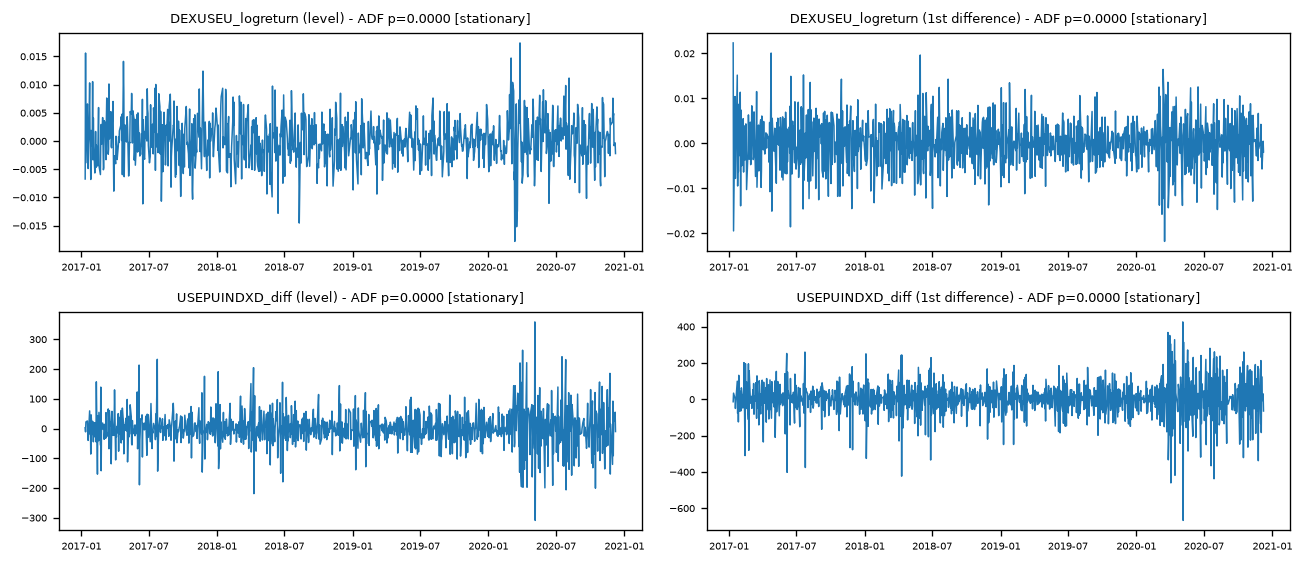

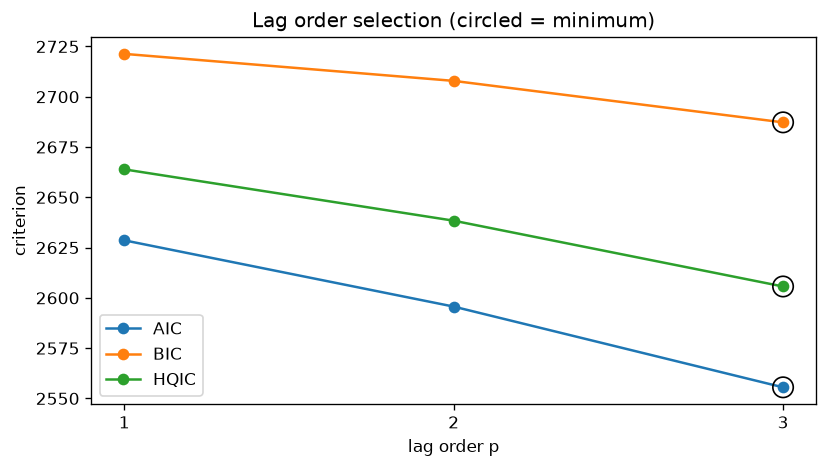

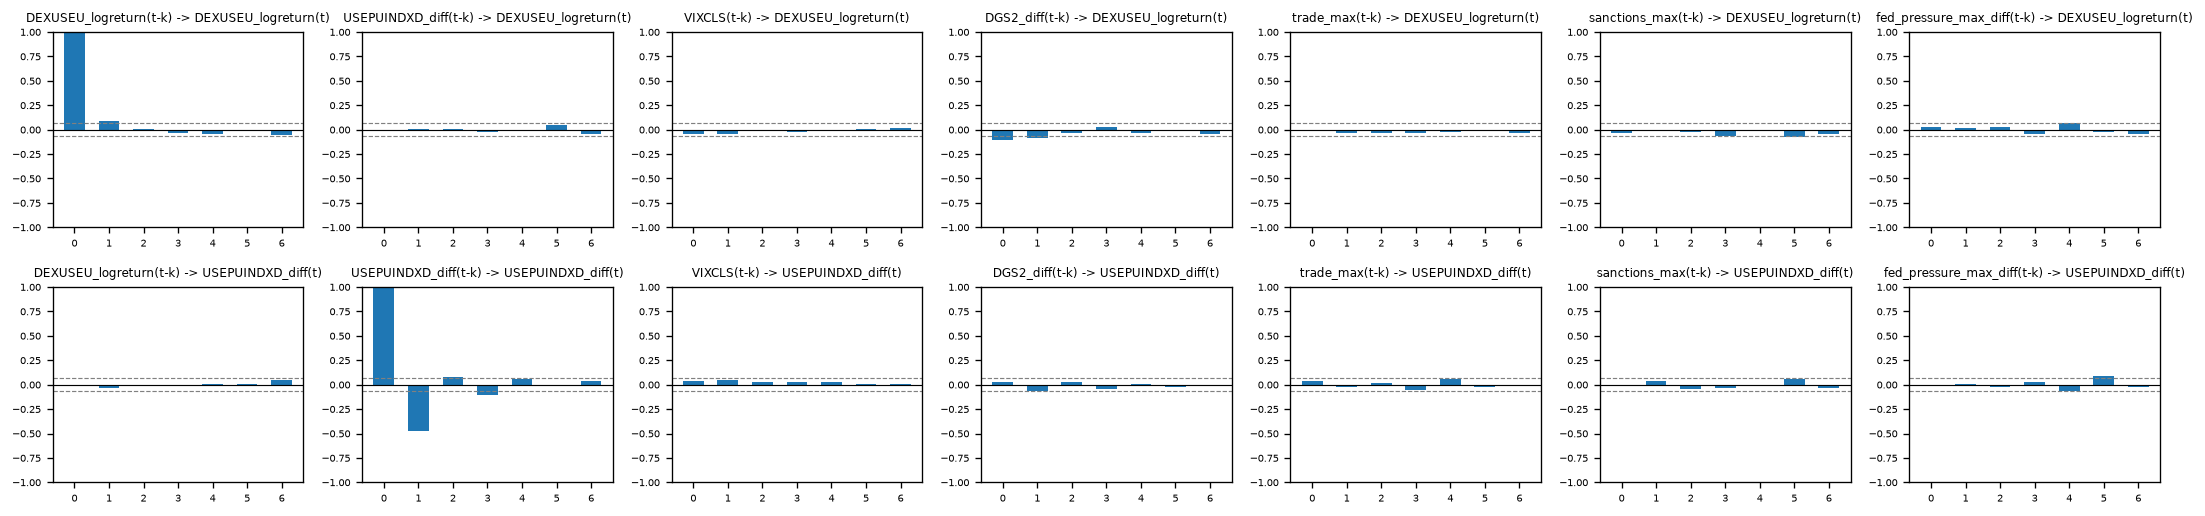

In [18]:
# PDF report for diagnostic Model 3a

figs = [
    plot_stationarity(etr),
    plot_lag_selection(lag_tbl),
    plot_cross_correlations(etr, xtr, max_lag=6)
]

generate_report(
    path="model3a_report.pdf",
    results=varx_res_scaled,
    endog=etr_scaled,
    exog=xtr_scaled,
    lag_tbl=lag_tbl,
    p=p_star,
    diag=diag_scaled,
    extra_figs=figs
)

print("Report generated: model3a_report.pdf")

## 5. Diagnostic Forecast Evaluation

The diagnostic Model 3a specification is evaluated over the final 20 observations excluded from estimation.

Forecast accuracy is first assessed in the stationary modelled space. EUR/USD log-return and Economic Policy Uncertainty forecasts are subsequently reconstructed into their original levels to permit an economically interpretable comparison with the observed series.

These forecasts are retained for comparison with the restricted macroeconomic baseline and the alternative geopolitical-index specifications, while recognising the non-convergence of Model 3a.

In [19]:
# Forecast held-out test period

fc_mean_scaled, fc_ci_scaled = forecast_varx(
    varx_res_scaled,
    steps=N_TEST,
    exog_future=xte_scaled
)

print("Forecast shape:", fc_mean_scaled.shape)

# Align forecast index with actual test dates
fc_mean_scaled.index = ete.index
fc_ci_scaled.index = ete.index

# Undo standardisation
fc_mean = (
    fc_mean_scaled * endog_std
    + endog_mean
)

fc_mean.index = ete.index

print("Forecast period:", fc_mean.index.min(), "to", fc_mean.index.max())
display(fc_mean.head())

Forecast shape: (20, 2)
Forecast period: 2020-12-09 00:00:00 to 2021-01-08 00:00:00


c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,DEXUSEU_logreturn,USEPUINDXD_diff
observation_date,,
2020-12-09,-0.000381,-15.593605
2020-12-10,0.000273,-0.342182
2020-12-11,0.000637,5.175954
2020-12-14,-0.000175,2.385711
2020-12-15,0.000254,-4.733096


In [20]:
# Evaluate forecast accuracy in modelled/transformed space

acc_transformed = forecast_accuracy(
    fc_mean,
    ete
)

print("Forecast accuracy in modelled space:")
print(acc_transformed)

Forecast accuracy in modelled space:
                      rmse      mae      me    mape    corr  rmse_vs_naive
DEXUSEU_logreturn   0.0028   0.0024 -0.0005  1.0500 -0.0385         0.6821
USEPUINDXD_diff    77.4203  68.2492  7.7713  0.9728  0.4895         0.5353


In [21]:
# Load raw EUR/USD and EPU levels for inverse transformation

eurusd_raw = pd.read_csv(
    r"C:\Users\franc\OneDrive\Geop-Model\data\raw\DEXUSEU.csv",
    parse_dates=["observation_date"]
).set_index("observation_date")

epu_raw = pd.read_csv(
    r"C:\Users\franc\OneDrive\Geop-Model\data\raw\USEPUINDXD.csv",
    parse_dates=["observation_date"]
).set_index("observation_date")
    
eurusd_levels = eurusd_raw["DEXUSEU"].sort_index()
epu_levels = epu_raw["USEPUINDXD"].sort_index()

forecast_dates = ete.index
test_start = forecast_dates.min()

last_eurusd_level = eurusd_levels.loc[
    eurusd_levels.index < test_start
].iloc[-1]

last_epu_level = epu_levels.loc[
    epu_levels.index < test_start
].iloc[-1]

print("Test starts:", test_start)
print("Last EUR/USD level before test:", last_eurusd_level)
print("Last EPU level before test:", last_epu_level)

Test starts: 2020-12-09 00:00:00
Last EUR/USD level before test: 1.2111
Last EPU level before test: 259.64


In [22]:
# Convert Model 3a forecasts back into original levels

fc_levels = pd.DataFrame(index=fc_mean.index)

# EUR/USD log returns -> EUR/USD spot level
fc_levels["DEXUSEU"] = (
    last_eurusd_level
    * np.exp(fc_mean["DEXUSEU_logreturn"].cumsum())
)

# EPU first differences -> EPU level
fc_levels["USEPUINDXD"] = (
    last_epu_level
    + fc_mean["USEPUINDXD_diff"].cumsum()
)

display(fc_levels.head())

,DEXUSEU,USEPUINDXD
observation_date,,
2020-12-09,1.210639,244.046395
2020-12-10,1.210970,243.704214
2020-12-11,1.211742,248.880168
2020-12-14,1.211530,251.265879
2020-12-15,1.211837,246.532783


In [23]:
# Actual original levels over the held-out test period

actual_levels = pd.DataFrame(index=forecast_dates)

actual_levels["DEXUSEU"] = eurusd_levels.reindex(forecast_dates)
actual_levels["USEPUINDXD"] = epu_levels.reindex(forecast_dates)

print("Missing actual level values:")
print(actual_levels.isna().sum())

display(actual_levels.head())

Missing actual level values:
DEXUSEU       0
USEPUINDXD    0
dtype: int64


,DEXUSEU,USEPUINDXD
observation_date,,
2020-12-09,1.2080,144.77
2020-12-10,1.2118,256.04
2020-12-11,1.2112,122.30
2020-12-14,1.2145,186.91
2020-12-15,1.2158,139.29


In [24]:
# Evaluate forecast accuracy in original level space

level_mask = actual_levels.notna().all(axis=1)

acc_levels = forecast_accuracy(
    fc_levels.loc[level_mask],
    actual_levels.loc[level_mask]
)

print("Forecast accuracy in original level space:")
print(acc_levels)

Forecast accuracy in original level space:
               rmse      mae       me   mape    corr  rmse_vs_naive
DEXUSEU      0.0112   0.0098  -0.0095  0.008  0.3945         3.2643
USEPUINDXD  88.9174  77.4887  55.7986  0.507  0.4148         1.1416


Model 3a forecast plots saved.


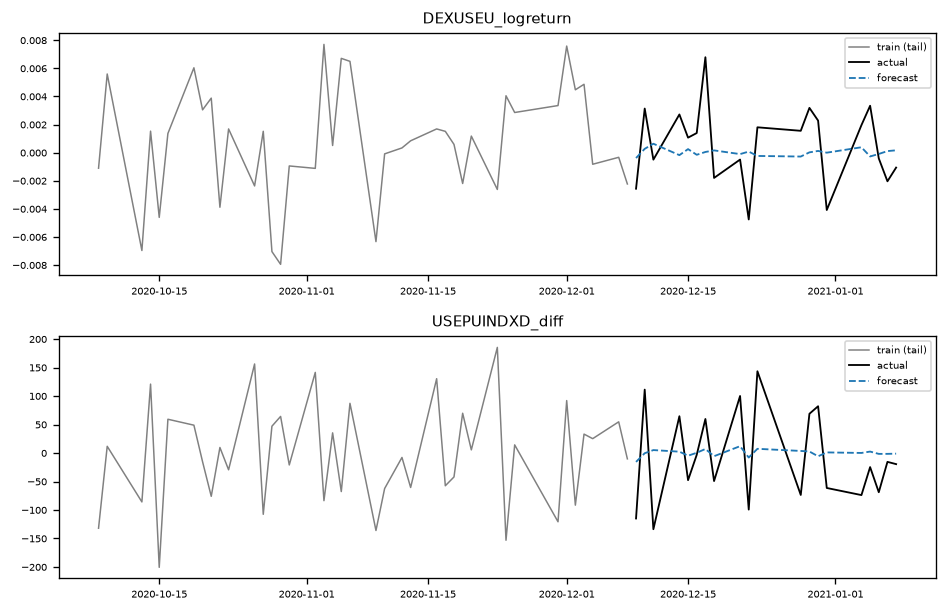

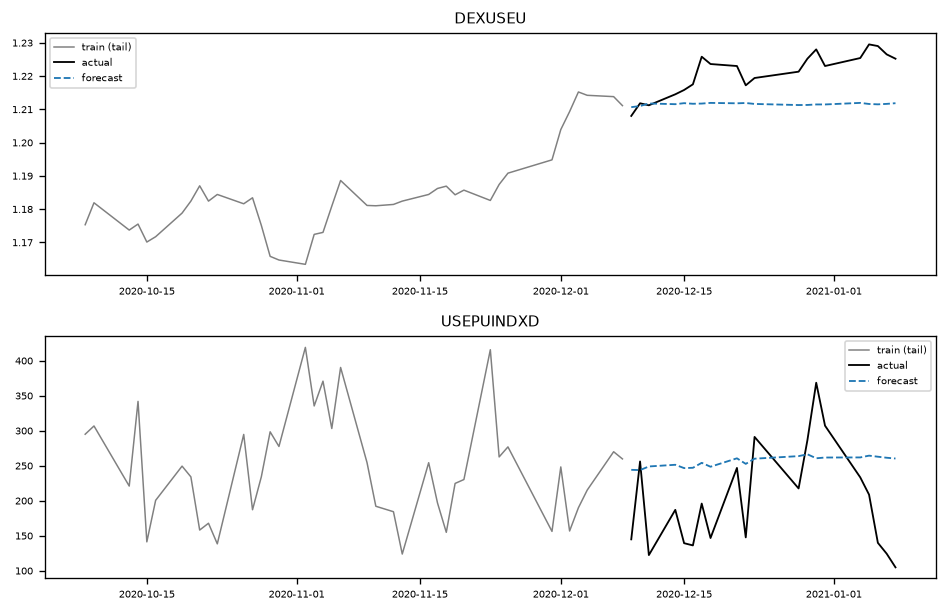

In [25]:
# Plot transformed/modelled-space forecasts

plot_forecast_vs_actual(
    fc_mean,
    ete,
    fc_ci=None,
    train_tail=etr.iloc[-40:],
    save_path="model3a_forecast_transformed.png"
)

# Build a short level-space training tail
level_train_tail = pd.DataFrame(index=etr.index[-40:])

level_train_tail["DEXUSEU"] = eurusd_levels.reindex(
    level_train_tail.index
)

level_train_tail["USEPUINDXD"] = epu_levels.reindex(
    level_train_tail.index
)

# Plot original-level forecasts

plot_forecast_vs_actual(
    fc_levels.loc[level_mask],
    actual_levels.loc[level_mask],
    fc_ci=None,
    train_tail=level_train_tail,
    save_path="model3a_forecast_levels.png"
)

print("Model 3a forecast plots saved.")

In [26]:
# Validate inverse transformations using ACTUAL test observations

actual_reconstructed = pd.DataFrame(index=ete.index)

# EUR/USD: reconstruct levels from actual log returns
actual_reconstructed["DEXUSEU"] = (
    last_eurusd_level
    * np.exp(ete["DEXUSEU_logreturn"].cumsum())
)

# EPU: reconstruct levels from actual first differences
actual_reconstructed["USEPUINDXD"] = (
    last_epu_level
    + ete["USEPUINDXD_diff"].cumsum()
)

# Compare reconstructed actuals with raw actual levels
round_trip_check = pd.DataFrame(index=ete.index)

round_trip_check["DEXUSEU_raw"] = actual_levels["DEXUSEU"]
round_trip_check["DEXUSEU_reconstructed"] = actual_reconstructed["DEXUSEU"]
round_trip_check["DEXUSEU_error"] = (
    round_trip_check["DEXUSEU_reconstructed"]
    - round_trip_check["DEXUSEU_raw"]
)

round_trip_check["USEPUINDXD_raw"] = actual_levels["USEPUINDXD"]
round_trip_check["USEPUINDXD_reconstructed"] = actual_reconstructed["USEPUINDXD"]
round_trip_check["USEPUINDXD_error"] = (
    round_trip_check["USEPUINDXD_reconstructed"]
    - round_trip_check["USEPUINDXD_raw"]
)

display(round_trip_check)

print(
    "Maximum EUR/USD reconstruction error:",
    round_trip_check["DEXUSEU_error"].abs().max()
)

print(
    "Maximum EPU reconstruction error:",
    round_trip_check["USEPUINDXD_error"].abs().max()
)

,DEXUSEU_raw,DEXUSEU_reconstructed,DEXUSEU_error,USEPUINDXD_raw,USEPUINDXD_reconstructed,USEPUINDXD_error
observation_date,,,,,,
2020-12-09,1.2080,1.2080,0.000000e+00,144.77,144.77,0.000000e+00
2020-12-10,1.2118,1.2118,2.220446e-16,256.04,256.04,0.000000e+00
2020-12-11,1.2112,1.2112,2.220446e-16,122.30,122.30,1.421085e-14
2020-12-14,1.2145,1.2145,0.000000e+00,186.91,186.91,2.842171e-14
2020-12-15,1.2158,1.2158,0.000000e+00,139.29,139.29,2.842171e-14
2020-12-16,1.2175,1.2175,0.000000e+00,136.12,136.12,0.000000e+00
2020-12-17,1.2258,1.2258,0.000000e+00,195.87,195.87,0.000000e+00
2020-12-18,1.2236,1.2236,2.220446e-16,146.67,146.67,2.842171e-14
2020-12-21,1.2230,1.2230,2.220446e-16,246.79,246.79,2.842171e-14


Maximum EUR/USD reconstruction error: 4.440892098500626e-16
Maximum EPU reconstruction error: 2.842170943040401e-14


## 6. Model Comparison Summary

A standardised summary of Model 3a is constructed for comparison with the restricted macroeconomic baseline and the alternative geopolitical specifications.

The summary records sample size, lag-selection and convergence information, information criteria, EUR/USD forecasting performance, and the statistical significance of the geopolitical coefficients where applicable.

This output is subsequently used in the combined model-comparison analysis.

In [29]:
# ============================================================
# MODEL 3a SUMMARY FOR MODEL COMPARISON
# ============================================================

MODEL_NAME = "3a"
GEOP_SPEC = "MAX"

# ------------------------------------------------------------
# 1. Lag-selection information
# ------------------------------------------------------------

selected_lag_row = lag_tbl.loc[p_star]

converged_lags = lag_tbl.index[
    lag_tbl["converged"] == True
].tolist()

any_lag_converged = len(converged_lags) > 0


# ------------------------------------------------------------
# 2. Identify geopolitical exogenous variables automatically
# ------------------------------------------------------------

trade_var = next(c for c in EXOG_COLS if c.startswith("trade_"))
sanctions_var = next(c for c in EXOG_COLS if c.startswith("sanctions_"))
fed_var = next(c for c in EXOG_COLS if c.startswith("fed_pressure_"))

print("Geopolitical variables used:")
print("Trade:", trade_var)
print("Sanctions:", sanctions_var)
print("Fed pressure:", fed_var)


# ------------------------------------------------------------
# 3. Extract geopolitical p-values from both equations
# ------------------------------------------------------------

pvals = varx_res_scaled.pvalues

# EUR/USD equation
trade_p_eurusd = pvals[f"beta.{trade_var}.DEXUSEU_logreturn"]
sanctions_p_eurusd = pvals[f"beta.{sanctions_var}.DEXUSEU_logreturn"]
fed_p_eurusd = pvals[f"beta.{fed_var}.DEXUSEU_logreturn"]

# EPU equation
trade_p_epu = pvals[f"beta.{trade_var}.USEPUINDXD_diff"]
sanctions_p_epu = pvals[f"beta.{sanctions_var}.USEPUINDXD_diff"]
fed_p_epu = pvals[f"beta.{fed_var}.USEPUINDXD_diff"]


# ------------------------------------------------------------
# 4. EUR/USD forecast accuracy in ORIGINAL LEVELS
# ------------------------------------------------------------

eurusd_accuracy = acc_levels.loc["DEXUSEU"]


# ------------------------------------------------------------
# 5. Build one-row summary table
# ------------------------------------------------------------

model_summary = pd.DataFrame([{

    # Identification
    "model": MODEL_NAME,
    "geopolitical_spec": GEOP_SPEC,

    # Sample
    "n_obs": len(model_df),
    "n_test": len(ete),

    # Lag selection
    "any_lag_converged": any_lag_converged,
    "converged_lags": ", ".join(map(str, converged_lags))
        if converged_lags else "None",
    "selected_lag": p_star,

    # Information criteria for selected lag
    "selected_lag_aic": selected_lag_row["aic"],
    "selected_lag_bic": selected_lag_row["bic"],
    "selected_lag_hqic": selected_lag_row["hqic"],

    # EUR/USD level forecast accuracy
    "eurusd_rmse": eurusd_accuracy["rmse"],
    "eurusd_mae": eurusd_accuracy["mae"],
    "eurusd_rmse_vs_naive": eurusd_accuracy["rmse_vs_naive"],

    # Final fitted-model convergence
    "final_model_converged":
        varx_res_scaled.mle_retvals.get("converged", None),

    # Geopolitical p-values — EUR/USD equation
    "trade_p_eurusd": trade_p_eurusd,
    "sanctions_p_eurusd": sanctions_p_eurusd,
    "fed_p_eurusd": fed_p_eurusd,

    # Geopolitical p-values — EPU equation
    "trade_p_epu": trade_p_epu,
    "sanctions_p_epu": sanctions_p_epu,
    "fed_p_epu": fed_p_epu,
}])


# ------------------------------------------------------------
# 6. Display and save
# ------------------------------------------------------------

display(model_summary.T)

summary_path = f"model{MODEL_NAME}_summary.csv"
model_summary.to_csv(summary_path, index=False)

print(f"Saved: {summary_path}")

Geopolitical variables used:
Trade: trade_max
Sanctions: sanctions_max
Fed pressure: fed_pressure_max_diff


,0
model,3a
geopolitical_spec,MAX
n_obs,992
n_test,20
any_lag_converged,False
converged_lags,None
selected_lag,3
selected_lag_aic,2555.520934
selected_lag_bic,2687.263541
selected_lag_hqic,2605.661285


Saved: model3a_summary.csv


## 7. Summary

Model 3a extends the selected Model 3 structure by introducing daily maximum measures of Trade Hostility, Sanctions Threat and Federal Reserve Pressure.

The daily maximum specification is designed to capture the most intense geopolitical signal within each category on each day. However, none of the candidate lag specifications converged successfully. Lag 3 was therefore retained only for diagnostic forecasting and comparison with the other geopolitical models.

Model 3a is consequently treated as an exploratory geopolitical specification rather than a fully viable final VAR-X model. Its results remain useful for assessing how the MAX representation compares with alternative aggregations of the same LLM-derived geopolitical information.